<a href="https://colab.research.google.com/github/Sunil032003/deep-learning-projects/blob/main/Convolutional_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objective:**
To build a convolutional autoencoder (CAE) thar compresses facial images into lower dimesional latent representaion and reconstruct with them with minimal loss information

#  Purpose

A convutional Autoencoder is a unsupervised deep learning model used for:

Image Compression image Reconstruction feaure extraction Dimensionality Reduction

The Encoder learns compressed represenatation (latent Space), while the decoder reconsructs the original image from the compressed represenatation

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [3]:
## create a samller Dataset (5000 Images)
Source_folder=os.path.join(path, "img_align_celeba", "img_align_celeba")

Destination_folder="celeba_small/faces"

os.makedirs(Destination_folder, exist_ok=True)

images=sorted(os.listdir(Source_folder))[:5000]

for image in images:
    shutil.copy(os.path.join(Source_folder, image),
                Destination_folder)
print("copied",len(images), "images")

copied 5000 images


In [4]:
#Data preprocessing
Image_size=(64,64)
Batch_size=32

In [5]:
datagen=ImageDataGenerator(rescale=1./255,
validation_split=0.2)

In [6]:
# Load Dataset
train_generator=datagen.flow_from_directory(
    "celeba_small",

    target_size=Image_size,

    batch_size=Batch_size,

    class_mode="input",

    subset="training"
)

Found 4000 images belonging to 1 classes.


In [7]:
validation_generator=datagen.flow_from_directory(
    "celeba_small",

    target_size=Image_size,

    batch_size=Batch_size,

    class_mode="input",

    subset="validation"
)

Found 1000 images belonging to 1 classes.


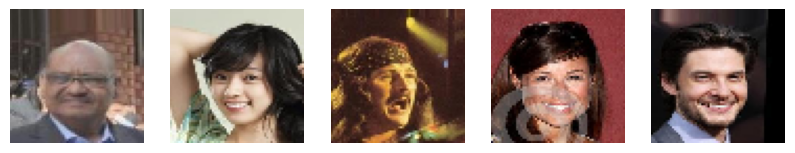

In [8]:
# Display Sample images
sample_images, _ = next(train_generator)
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1),
    plt.imshow(sample_images[i])
    plt.axis("off")
plt.show()

In [24]:
from tensorflow.keras.optimizers import Adam

In [49]:
#Build Convolutional Autoencoder
#Encoder
input_img=Input(shape=(64,64,3))

x=Conv2D(32,(3,3),
         activation="relu",
         padding="same")(input_img)
x=MaxPooling2D((2,2),
              padding="same")(x)

x=Conv2D(64,(3,3),
         activation="relu",
         padding="same")(x)
x=MaxPooling2D((2,2),
              padding="same")(x)
x=Conv2D(128,(3,3),
         activation="relu",
         padding="same")(x)

encoded=MaxPooling2D((2,2),padding="same")(x)

# Decoder
x=Conv2D(128,(3,3),
         activation="relu",
         padding="same")(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(64,(3,3),
         activation='relu',
         padding="same")(x)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),
         activation='relu',
         padding="same")(x)
x=UpSampling2D((2,2))(x)

decoded=Conv2D(3,(3,3),
               activation="sigmoid",
               padding="same")(x)

#create model
autoencoder=Model(input_img,
                  decoded)
#compile model
autoencoder.compile(optimizer=Adam(learning_rate=0.0001),
                    loss="mse")

#train model
history=autoencoder.fit(train_generator,
                        validation_data=validation_generator,
                        epochs=15)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0484 - val_loss: 0.0248
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0220 - val_loss: 0.0187
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0174 - val_loss: 0.0158
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0150 - val_loss: 0.0141
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0138 - val_loss: 0.0131
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0130 - val_loss: 0.0131
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0124 - val_loss: 0.0119
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0120 - val_loss: 0.0116
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0116 - val_loss: 0.0115
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0111 - val_loss: 0.0108
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 

In [55]:
history=autoencoder.fit(train_generator,
                        validation_data=validation_generator,
                        epochs=35)

Epoch 1/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0101 - val_loss: 0.0101
Epoch 2/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0100 - val_loss: 0.0101
Epoch 3/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0098 - val_loss: 0.0096
Epoch 4/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 5/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0096 - val_loss: 0.0093
Epoch 6/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 7/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0094 - val_loss: 0.0091
Epoch 8/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0092 - val_loss: 0.0091
Epoch 9/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0092 - val_loss: 0.0090
Epoch 10/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0091 - val_loss: 0.0090
Epoch 11/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0090 - val_loss: 0.0089
Epoch 12/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 

In [56]:
autoencoder.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_201 (Conv2D)             │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_86 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_202 (Conv2D)             │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_87 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_203 (Conv2D)             │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_204 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_93 (UpSampling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_205 (Conv2D)             │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_94 (UpSampling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_206 (Conv2D)             │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_95 (UpSampling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_207 (Conv2D)             │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,001,867 (3.82 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,912 (2.55 MB)

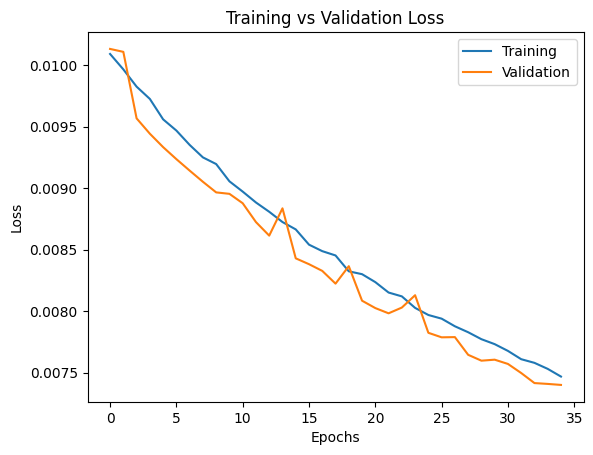

In [57]:
#plot loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Training","Validation"])
plt.show()

In [58]:
#Evaluate model
loss=autoencoder.evaluate(validation_generator)
print("Validation Loss:", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0074
Validation Loss: 0.007399744354188442


In [59]:
#Reconstruct Image
sample_images, _ = next(validation_generator)
reconstructed_images = autoencoder.predict(sample_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


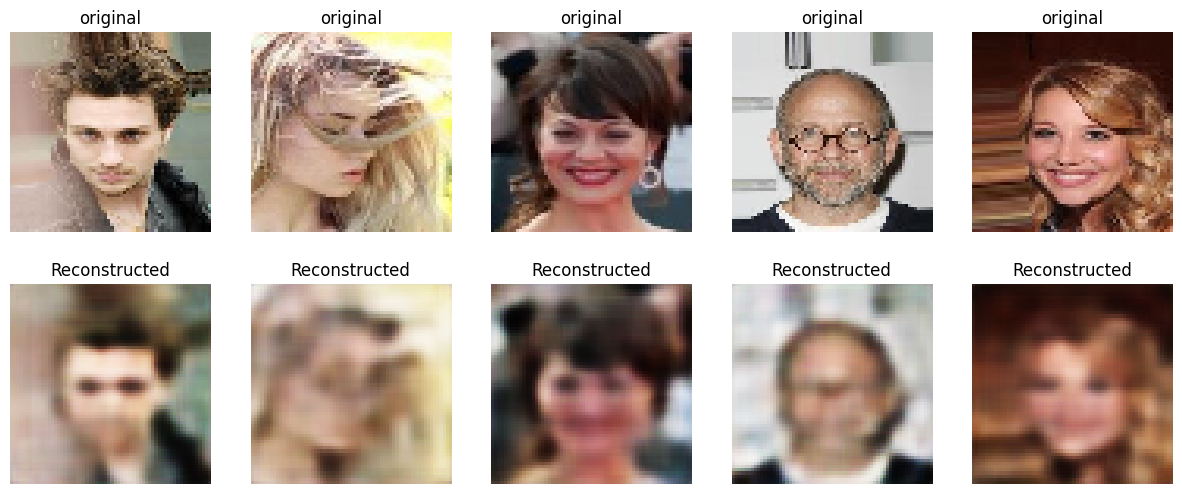

In [60]:
#Display Results
plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(2, 5, i+1),
    plt.imshow(sample_images[i])
    plt.title("original")
    plt.axis("off")
    plt.subplot(2, 5, i+6),
    plt.imshow(reconstructed_images[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()